In [3]:
import pandas as pd

class DatasetLoader:
    """
    Responsible only for loading the dataset.
    (Single Responsibility Principle)
    """

    def __init__(self, file_path):
        self.file_path = file_path

    def load_data(self):
        try:
            df = pd.read_csv(self.file_path)
            print("Dataset loaded successfully.")
            print(f"Total Records : {len(df)}")
            print(f"Total Columns : {len(df.columns)}")
            return df

        except FileNotFoundError:
            print(" Dataset file not found.")
            return None

        except Exception as e:
            print("Error:", e)
            return None

In [5]:
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Dataset Books.csv"

loader = DatasetLoader(file_path)

df = loader.load_data()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully.
Total Records : 3876
Total Columns : 7


In [7]:
class DataCleaner:
    """
    Responsible only for cleaning the dataset.
    """

    def clean_data(self, df):

        # Remove duplicate rows
        df = df.drop_duplicates()

        # Remove spaces from column names
        df.columns = df.columns.str.strip()

        # Remove spaces from string values
        for column in df.select_dtypes(include="object"):
            df[column] = df[column].astype(str).str.strip()

        print("Dataset cleaned successfully.")
        print(f"Remaining Records: {len(df)}")

        return df

In [8]:
cleaner = DataCleaner()

df = cleaner.clean_data(df)

df.head()

Dataset cleaned successfully.
Remaining Records: 3876


,book,author,publication date,language,book publisher,ISBN,BNB id
0,World politics : international relations and g...,Jeffrey Haynes,2023,English,SAGE,1529613827,GBC315766
1,World music : a global journey,Terry E. Miller,2023,English,Routledge,1000909531/1000909517,GBC397766
2,Reflections of deviance,A. J. Cross,2023,English,Severn House,1448308019,GBC2M0828
3,Reduction theory and arithmetic groups,Joachim Schwermer,2023,English,Cambridge University Press,1108832038,GBC2F3287
4,Embracing technology in the early years : a pr...,Fiona Joines,2023,English,Routledge,1000932218,GBC3C1738


In [9]:
class DataValidator:
    """
    Responsible only for validating the dataset.
    """

    def validate(self, df):

        print("========== DATASET VALIDATION ==========")

        # Dataset size
        print(f"\nRows    : {df.shape[0]}")
        print(f"Columns : {df.shape[1]}")

        # Missing values
        print("\nMissing Values")
        print(df.isnull().sum())

        # Duplicate rows
        duplicates = df.duplicated().sum()
        print(f"\nDuplicate Rows : {duplicates}")

        print("\nValidation Completed Successfully.")

        return True

In [10]:
validator = DataValidator()

validator.validate(df)

========== DATASET VALIDATION ==========

Rows    : 3876
Columns : 7

Missing Values
book                0
author              0
publication date    0
language            0
book publisher      0
ISBN                0
BNB id              0
dtype: int64

Duplicate Rows : 0

Validation Completed Successfully.


True

In [36]:
import matplotlib.pyplot as plt

class PublicationAnalyzer(BaseAnalyzer):
    """
    Responsible only for publication trend analysis.
    """

    def __init__(self, df):
        super().__init__(df)

    def analyze(self):

        publication_counts = (
            self.df["publication date"]
            .value_counts()
            .sort_index()
        )

        print("Publication Trend Summary")
        print(publication_counts.head(10))

        return publication_counts

    def plot(self):

        publication_counts = (
            self.df["publication date"]
            .value_counts()
            .sort_index()
        )

        plt.figure(figsize=(10,5))

        publication_counts.plot(kind="line")

        plt.title("Publication Trends Over Time")
        plt.xlabel("Publication Year")
        plt.ylabel("Number of Books")

        plt.grid(True)

        plt.show()

Publication Trend Summary
publication date
2011    290
2012    237
2013    135
2014    187
2015    333
2016    219
2017    352
2018    228
2019    530
2020    461
Name: count, dtype: int64


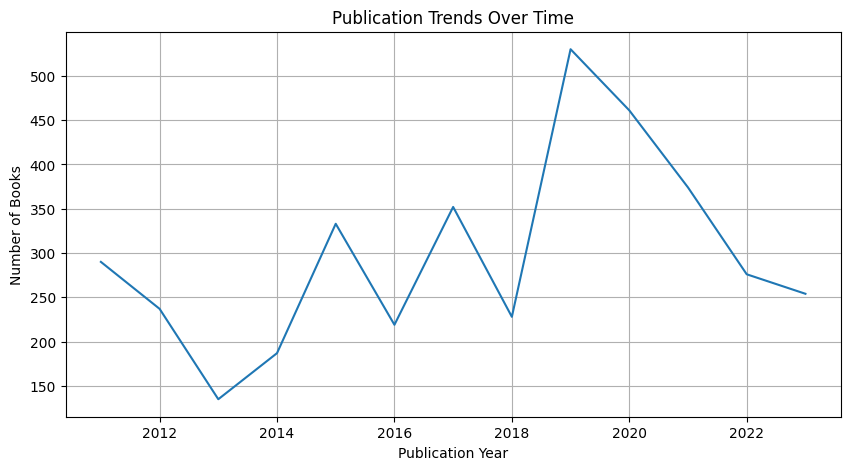

In [12]:
publication = PublicationAnalyzer(df)

publication.analyze()

publication.plot()

In [37]:
class AuthorAnalyzer(BaseAnalyzer):
    """
    Responsible only for author analysis.
    """

    def __init__(self, df):
        super().__init__(df)

    def analyze(self):

        author_counts = (
            self.df["author"]
            .value_counts()
            .head(5)
        )

        print("Top 5 Authors")
        print(author_counts)

        return author_counts

    def plot(self):

        author_counts = (
            self.df["author"]
            .value_counts()
            .head(5)
        )

        author_counts.plot(kind="bar", figsize=(8,5))

        plt.title("Top 5 Most Prolific Authors")
        plt.xlabel("Author")
        plt.ylabel("Number of Books")

        plt.show()

Top 5 Authors
author
Alison Roberts                     131
Muḥammad Ṣādiq Muḥammad Karbāsī     33
Zuri Day                            27
Barrie Gunter                       25
Valerie Jackson                     22
Name: count, dtype: int64


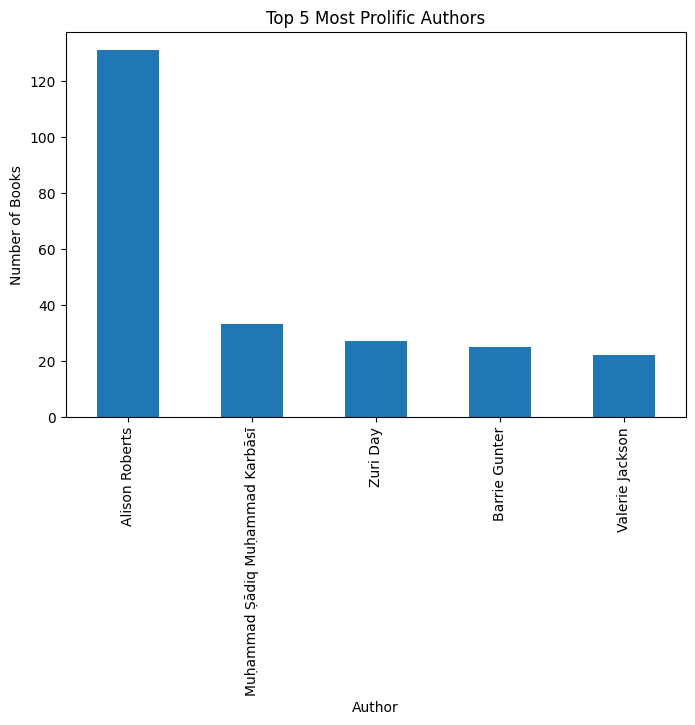

In [14]:
author = AuthorAnalyzer(df)

author.analyze()

author.plot()

In [15]:
class BaseAnalyzer:
    """
    Base class for all analyzers.
    """

    def __init__(self, df):
        self.df = df

    def analyze(self):
        raise NotImplementedError("Subclasses must implement analyze().")

    def plot(self):
        raise NotImplementedError("Subclasses must implement plot().")

In [38]:
class LanguageAnalyzer(BaseAnalyzer):
    """
    Responsible only for language analysis.
    """

    def __init__(self, df):
        super().__init__(df)

    def analyze(self):

        language_counts = (
            self.df["language"]
            .value_counts()
        )

        print("Language Distribution")
        print(language_counts)

        return language_counts

    def plot(self):

        language_counts = (
            self.df["language"]
            .value_counts()
            .head(10)
        )

        plt.figure(figsize=(10,5))

        language_counts.plot(kind="bar")

        plt.title("Top 10 Languages")
        plt.xlabel("Language")
        plt.ylabel("Number of Books")

        plt.xticks(rotation=45)

        plt.show()

Language Distribution
language
English       2398
Arabic         300
Russian        207
German         163
French         132
Italian        124
Spanish        112
Chinese         94
Swedish         70
Turkish         70
Korean          61
Japanese        39
Polish          39
Thai            18
Tamil           14
Welsh           11
Mongolian        9
Bulgarian        5
Sinhala          4
Irish            2
Latin            1
Portuguese       1
Marathi          1
Malayalam        1
Name: count, dtype: int64


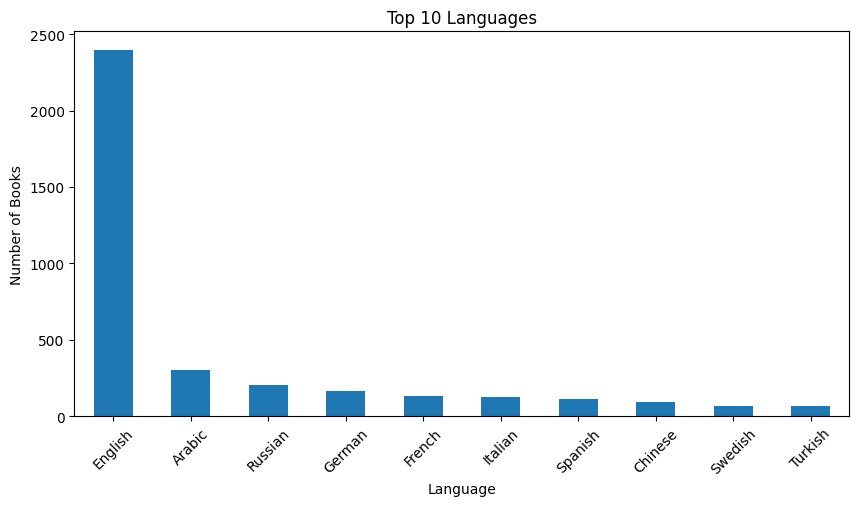

In [23]:
language = LanguageAnalyzer(df)

language.analyze()

language.plot()


In [26]:
class PublisherAnalyzer:
    """
    Responsible only for publisher analysis.
    """

    def __init__(self, df):
        self.df = df

    def analyze(self):

        publisher_counts = (
            self.df["book publisher"]
            .value_counts()
            .head(10)
        )

        print("Top 10 Publishers")
        print(publisher_counts)

        return publisher_counts

    def plot(self):

        publisher_counts = (
            self.df["book publisher"]
            .value_counts()
            .head(10)
        )

        plt.figure(figsize=(12,6))

        publisher_counts.plot(kind="bar")

        plt.title("Top 10 Publishers")
        plt.xlabel("Publisher")
        plt.ylabel("Number of Books")

        plt.xticks(rotation=45, ha="right")

        plt.tight_layout()

        plt.show()

Top 10 Publishers
book publisher
: Springer         321
AcademicaPress     268
Routledge          254
Adams Media        210
Mills&Boon         152
nan                 73
Crossway            46
Elsevier/Masson     44
Rack Press          42
Zone Books          37
Name: count, dtype: int64


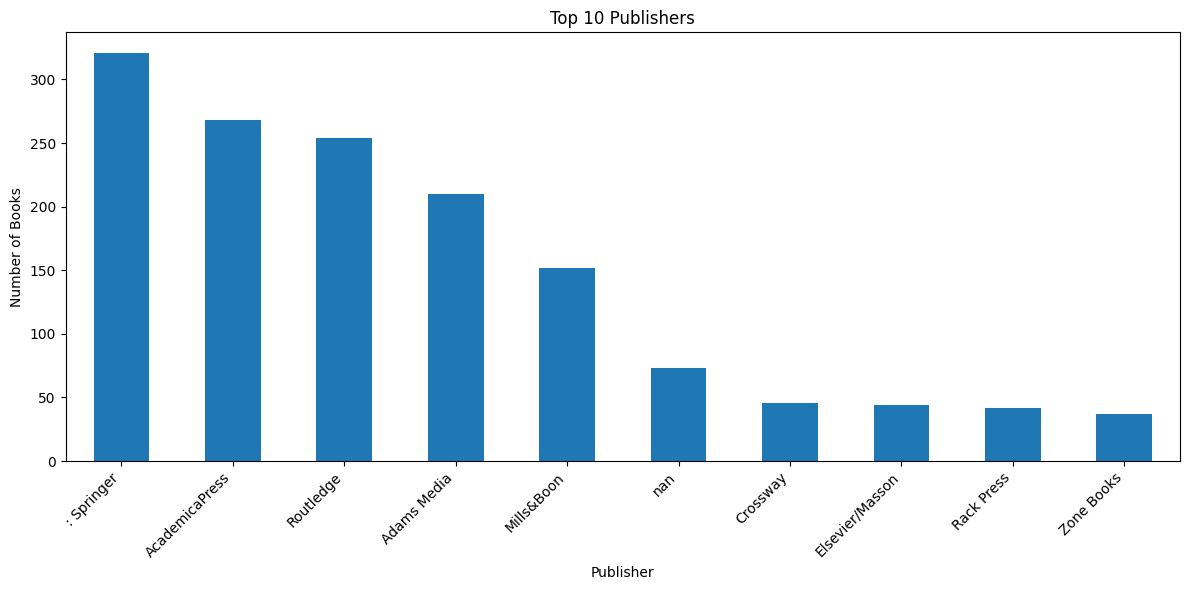

In [27]:
publisher = PublisherAnalyzer(df)

publisher.analyze()

publisher.plot()

In [30]:
class ISBNAnalyzer:
    """
    Responsible only for ISBN analysis.
    """

    def __init__(self, df):
        self.df = df

    def analyze(self):

        missing = self.df["ISBN"].isnull().sum()

        total = len(self.df)

        percentage = (missing / total) * 100

        print("ISBN Analysis")
        print(f"Total Records : {total}")
        print(f"Missing ISBN : {missing}")
        print(f"Percentage : {percentage:.2f}%")

        return missing, percentage

    def plot(self):

        missing = self.df["ISBN"].isnull().sum()

        available = len(self.df) - missing

        plt.figure(figsize=(6,6))

        plt.pie(
            [available, missing],
            labels=["Available ISBN", "Missing ISBN"],
            autopct="%1.1f%%",
            startangle=90
        )

        plt.title("ISBN Availability")

        plt.show()

ISBN Analysis
Total Records : 3876
Missing ISBN : 0
Percentage : 0.00%


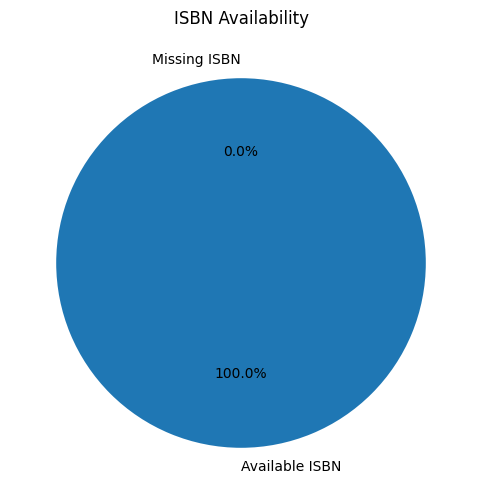

In [31]:
isbn = ISBNAnalyzer(df)

isbn.analyze()

isbn.plot()

In [32]:
publication = PublicationAnalyzer(df)
author = AuthorAnalyzer(df)
language = LanguageAnalyzer(df)

Publication Trend Summary
publication date
2011    290
2012    237
2013    135
2014    187
2015    333
2016    219
2017    352
2018    228
2019    530
2020    461
Name: count, dtype: int64


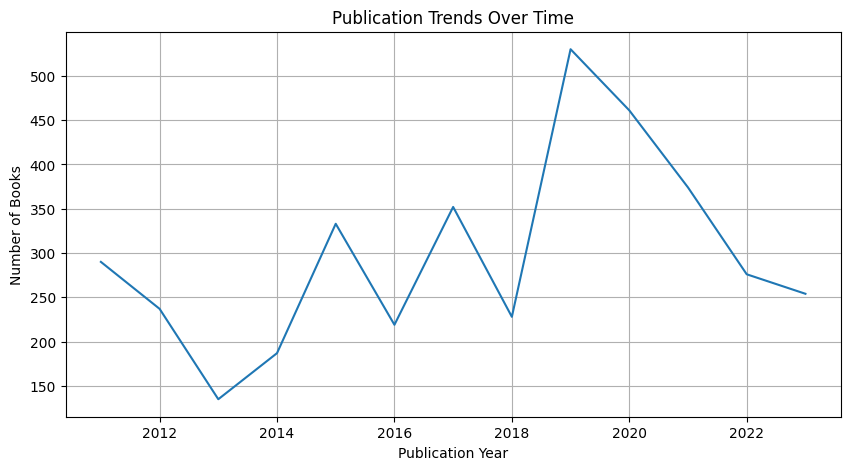

Top 5 Authors
author
Alison Roberts                     131
Muḥammad Ṣādiq Muḥammad Karbāsī     33
Zuri Day                            27
Barrie Gunter                       25
Valerie Jackson                     22
Name: count, dtype: int64


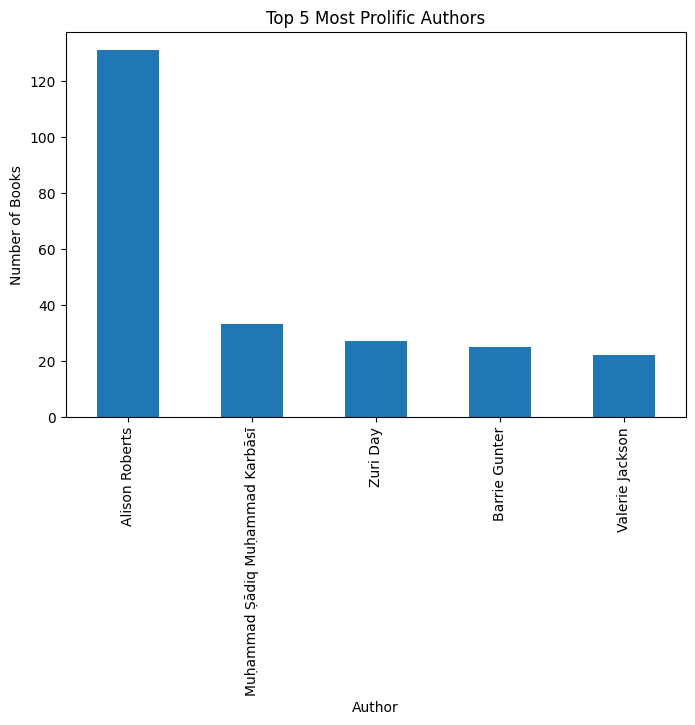

Language Distribution
language
English       2398
Arabic         300
Russian        207
German         163
French         132
Italian        124
Spanish        112
Chinese         94
Swedish         70
Turkish         70
Korean          61
Japanese        39
Polish          39
Thai            18
Tamil           14
Welsh           11
Mongolian        9
Bulgarian        5
Sinhala          4
Irish            2
Latin            1
Portuguese       1
Marathi          1
Malayalam        1
Name: count, dtype: int64


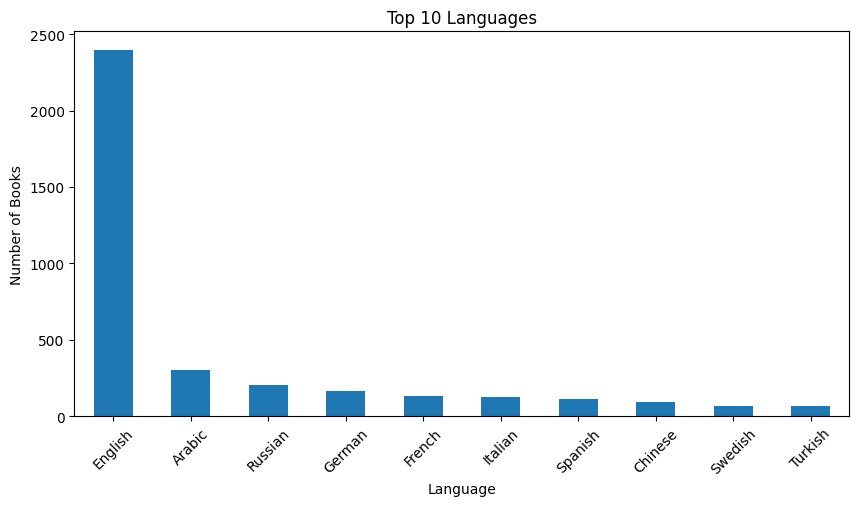

In [39]:
class AnalysisFactory:
    def __init__(self, df):
        self.df = df

    def create_analyzer(self, analyzer_type):
        if analyzer_type == "publication":
            return PublicationAnalyzer(self.df)
        elif analyzer_type == "author":
            return AuthorAnalyzer(self.df)
        elif analyzer_type == "language":
            return LanguageAnalyzer(self.df)
        elif analyzer_type == "publisher":
            return PublisherAnalyzer(self.df)
        elif analyzer_type == "isbn":
            return ISBNAnalyzer(self.df)
        else:
            raise ValueError(f"Unknown analyzer type: {analyzer_type}")

factory = AnalysisFactory(df)

publication_analyzer = factory.create_analyzer("publication")
author_analyzer = factory.create_analyzer("author")
language_analyzer = factory.create_analyzer("language")

publication_analyzer.analyze()
publication_analyzer.plot()
author_analyzer.analyze()
author_analyzer.plot()
language_analyzer.analyze()
language_analyzer.plot()

Publication Trend Summary
publication date
2011    290
2012    237
2013    135
2014    187
2015    333
2016    219
2017    352
2018    228
2019    530
2020    461
Name: count, dtype: int64


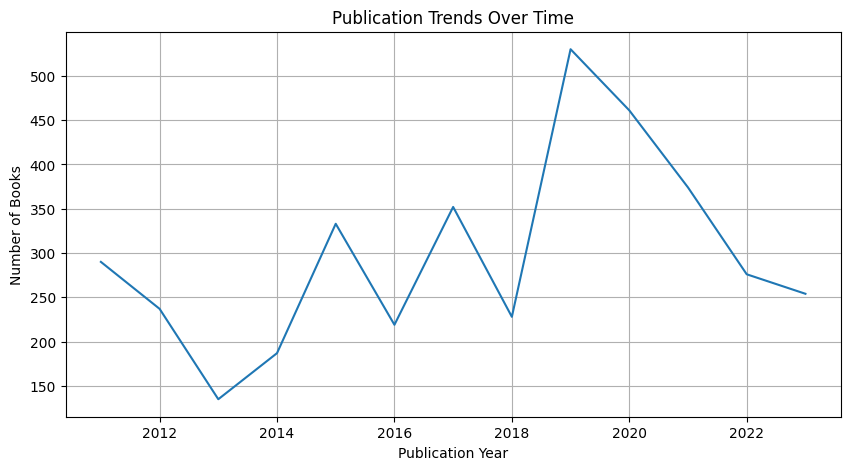

In [40]:
publication = PublicationAnalyzer(df)
publication.analyze()
publication.plot()

Top 5 Authors
author
Alison Roberts                     131
Muḥammad Ṣādiq Muḥammad Karbāsī     33
Zuri Day                            27
Barrie Gunter                       25
Valerie Jackson                     22
Name: count, dtype: int64


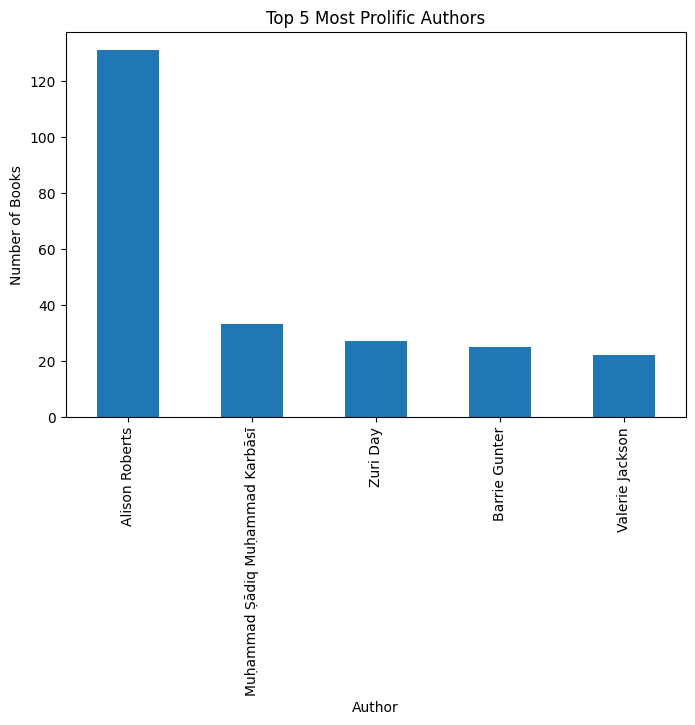

In [41]:
author = AuthorAnalyzer(df)
author.analyze()
author.plot()

Language Distribution
language
English       2398
Arabic         300
Russian        207
German         163
French         132
Italian        124
Spanish        112
Chinese         94
Swedish         70
Turkish         70
Korean          61
Japanese        39
Polish          39
Thai            18
Tamil           14
Welsh           11
Mongolian        9
Bulgarian        5
Sinhala          4
Irish            2
Latin            1
Portuguese       1
Marathi          1
Malayalam        1
Name: count, dtype: int64


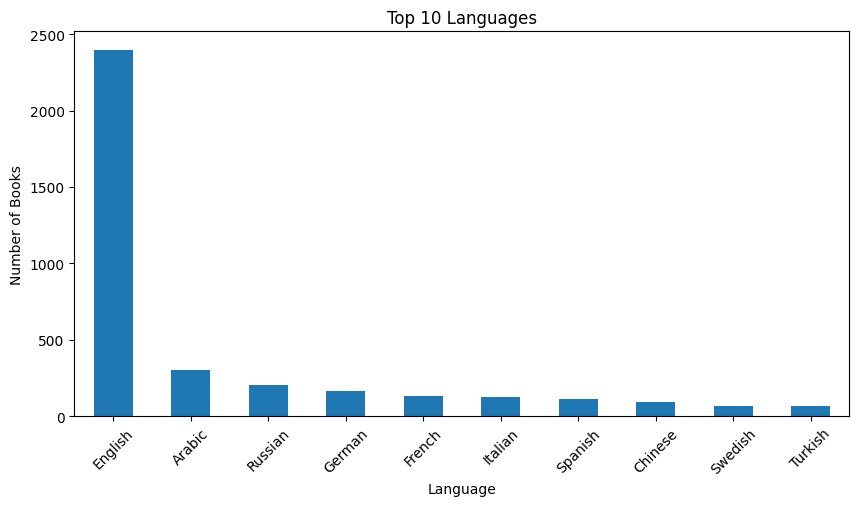

In [42]:
language = LanguageAnalyzer(df)
language.analyze()
language.plot()

Top 10 Publishers
book publisher
: Springer         321
AcademicaPress     268
Routledge          254
Adams Media        210
Mills&Boon         152
nan                 73
Crossway            46
Elsevier/Masson     44
Rack Press          42
Zone Books          37
Name: count, dtype: int64


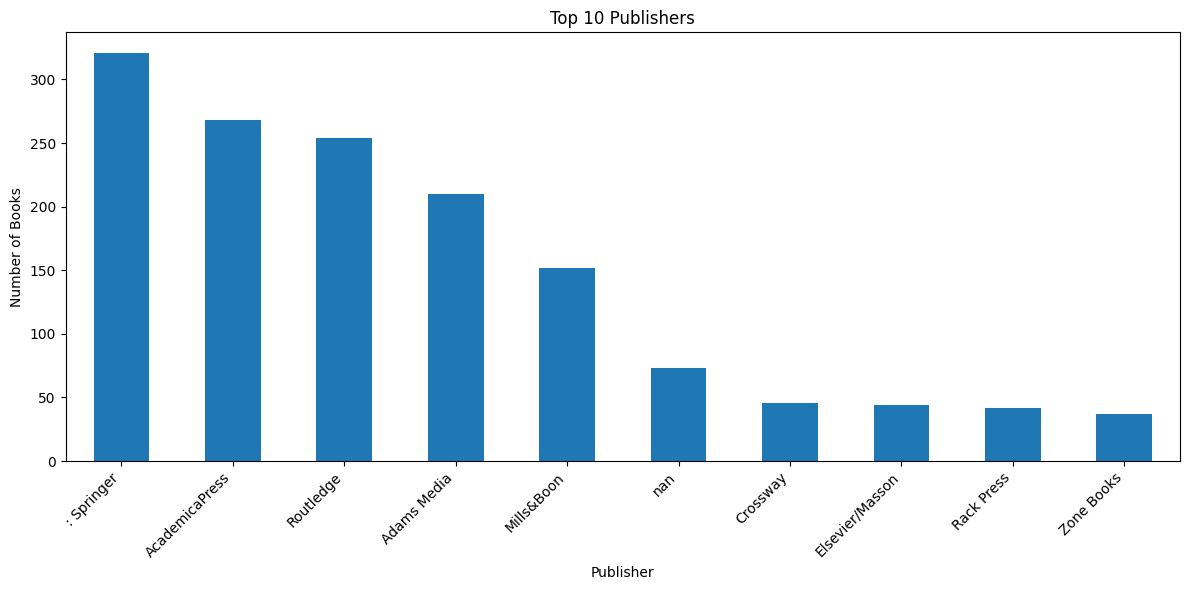

In [43]:
publisher = PublisherAnalyzer(df)
publisher.analyze()
publisher.plot()

ISBN Analysis
Total Records : 3876
Missing ISBN : 0
Percentage : 0.00%


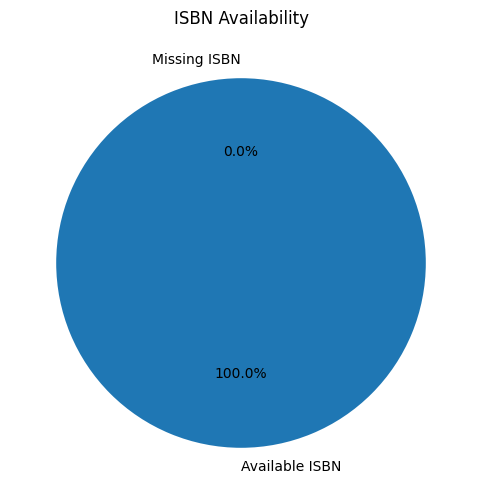

In [44]:
isbn = ISBNAnalyzer(df)
isbn.analyze()
isbn.plot()

In [45]:
class ChartGenerator:
    """
    Responsible only for generating charts.
    """

    def bar_chart(self, data, title, xlabel, ylabel):

        plt.figure(figsize=(10,5))

        data.plot(kind="bar")

        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)

        plt.xticks(rotation=45)

        plt.tight_layout()

        plt.show()

    def line_chart(self, data, title, xlabel, ylabel):

        plt.figure(figsize=(10,5))

        data.plot(kind="line")

        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)

        plt.grid(True)

        plt.tight_layout()

        plt.show()

    def pie_chart(self, data, title):

        plt.figure(figsize=(7,7))

        data.plot(
            kind="pie",
            autopct="%1.1f%%",
            startangle=90
        )

        plt.title(title)
        plt.ylabel("")

        plt.tight_layout()

        plt.show()

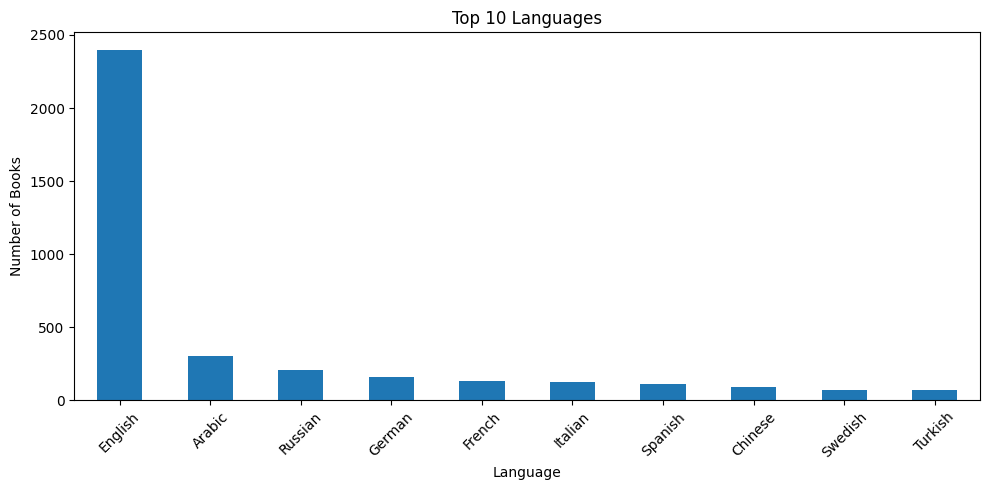

In [46]:
chart = ChartGenerator()

language_counts = df["language"].value_counts().head(10)

chart.bar_chart(
    language_counts,
    "Top 10 Languages",
    "Language",
    "Number of Books"
)

In [55]:
class AnalysisFactory:

    def __init__(self, df):
        self.df = df

    def create_analyzer(self, analysis_type):

        if analysis_type == "publication":
            return PublicationAnalyzer(self.df)

        elif analysis_type == "author":
            return AuthorAnalyzer(self.df)

        elif analysis_type == "language":
            return LanguageAnalyzer(self.df)

        elif analysis_type == "publisher":
            return PublisherAnalyzer(self.df)

        elif analysis_type == "isbn":
            return ISBNAnalyzer(self.df)

        elif analysis_type == "year_language":
            return YearLanguageAnalyzer(self.df)
        else:
            raise ValueError("Invalid Analysis Type")

In [48]:
factory = AnalysisFactory(df)

Publication Trend Summary
publication date
2011    290
2012    237
2013    135
2014    187
2015    333
2016    219
2017    352
2018    228
2019    530
2020    461
Name: count, dtype: int64


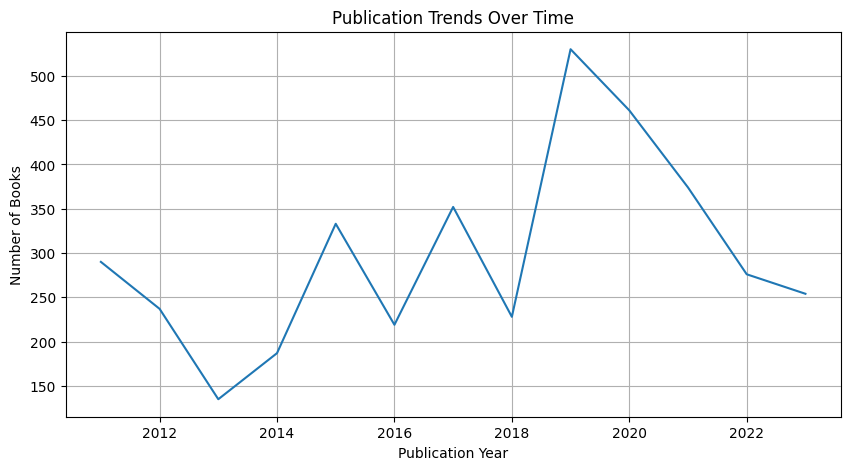

In [49]:
publication = factory.create_analyzer("publication")

publication.analyze()

publication.plot()

Top 5 Authors
author
Alison Roberts                     131
Muḥammad Ṣādiq Muḥammad Karbāsī     33
Zuri Day                            27
Barrie Gunter                       25
Valerie Jackson                     22
Name: count, dtype: int64


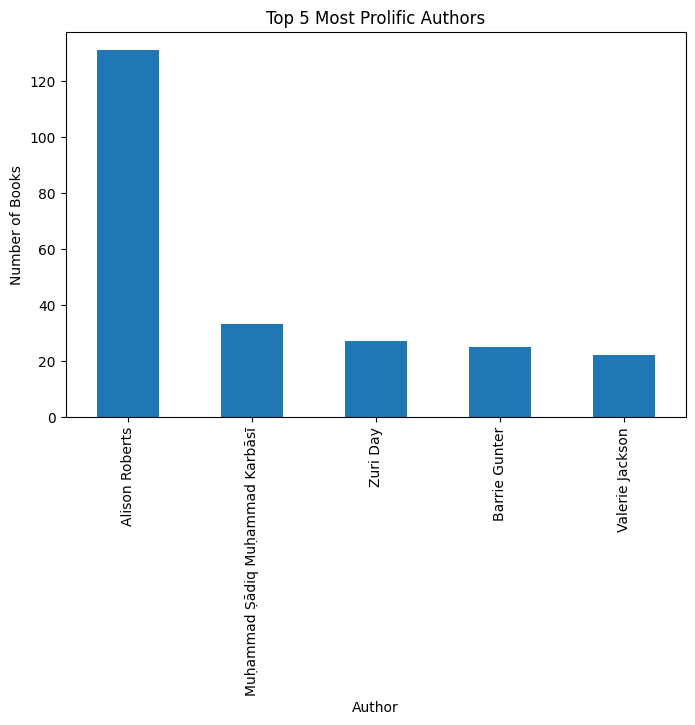

In [50]:
author = factory.create_analyzer("author")

author.analyze()

author.plot()

Language Distribution
language
English       2398
Arabic         300
Russian        207
German         163
French         132
Italian        124
Spanish        112
Chinese         94
Swedish         70
Turkish         70
Korean          61
Japanese        39
Polish          39
Thai            18
Tamil           14
Welsh           11
Mongolian        9
Bulgarian        5
Sinhala          4
Irish            2
Latin            1
Portuguese       1
Marathi          1
Malayalam        1
Name: count, dtype: int64


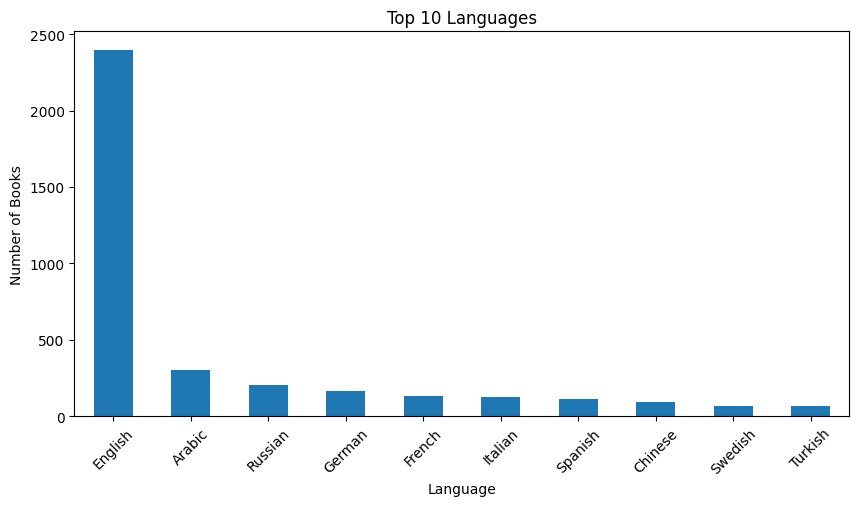

In [51]:
language = factory.create_analyzer("language")

language.analyze()

language.plot()

In [52]:
def main():

    factory = AnalysisFactory(df)

    while True:

        print("\n==============================")
        print(" DREAM BOOK SHOP ANALYSIS ")
        print("==============================")
        print("1. Publication Analysis")
        print("2. Author Analysis")
        print("3. Language Analysis")
        print("4. Publisher Analysis")
        print("5. ISBN Analysis")
        print("6. Exit")

        choice = input("\nEnter your choice: ")

        if choice == "1":
            analyzer = factory.create_analyzer("publication")
            analyzer.analyze()
            analyzer.plot()

        elif choice == "2":
            analyzer = factory.create_analyzer("author")
            analyzer.analyze()
            analyzer.plot()

        elif choice == "3":
            analyzer = factory.create_analyzer("language")
            analyzer.analyze()
            analyzer.plot()

        elif choice == "4":
            analyzer = factory.create_analyzer("publisher")
            analyzer.analyze()
            analyzer.plot()

        elif choice == "5":
            analyzer = factory.create_analyzer("isbn")
            analyzer.analyze()
            analyzer.plot()

        elif choice == "6":
            print("Thank you for using Dream Book Shop Analysis System.")
            break

        else:
            print("Invalid Choice. Please try again.")


 DREAM BOOK SHOP ANALYSIS 
1. Publication Analysis
2. Author Analysis
3. Language Analysis
4. Publisher Analysis
5. ISBN Analysis
6. Exit

Enter your choice: 1
Publication Trend Summary
publication date
2011    290
2012    237
2013    135
2014    187
2015    333
2016    219
2017    352
2018    228
2019    530
2020    461
Name: count, dtype: int64


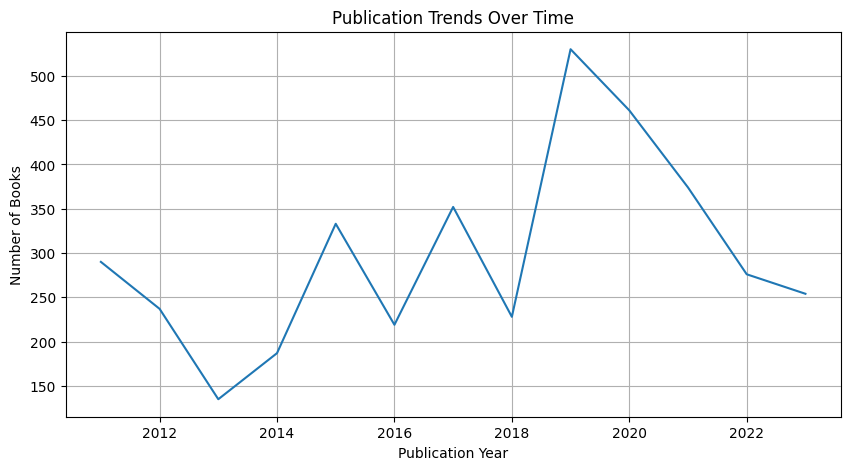


 DREAM BOOK SHOP ANALYSIS 
1. Publication Analysis
2. Author Analysis
3. Language Analysis
4. Publisher Analysis
5. ISBN Analysis
6. Exit

Enter your choice: 2
Top 5 Authors
author
Alison Roberts                     131
Muḥammad Ṣādiq Muḥammad Karbāsī     33
Zuri Day                            27
Barrie Gunter                       25
Valerie Jackson                     22
Name: count, dtype: int64


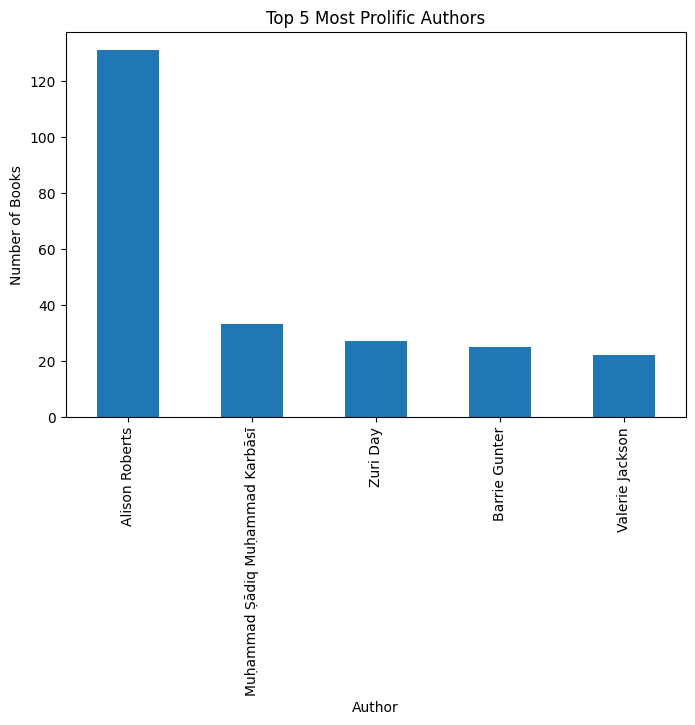


 DREAM BOOK SHOP ANALYSIS 
1. Publication Analysis
2. Author Analysis
3. Language Analysis
4. Publisher Analysis
5. ISBN Analysis
6. Exit

Enter your choice: 3
Language Distribution
language
English       2398
Arabic         300
Russian        207
German         163
French         132
Italian        124
Spanish        112
Chinese         94
Swedish         70
Turkish         70
Korean          61
Japanese        39
Polish          39
Thai            18
Tamil           14
Welsh           11
Mongolian        9
Bulgarian        5
Sinhala          4
Irish            2
Latin            1
Portuguese       1
Marathi          1
Malayalam        1
Name: count, dtype: int64


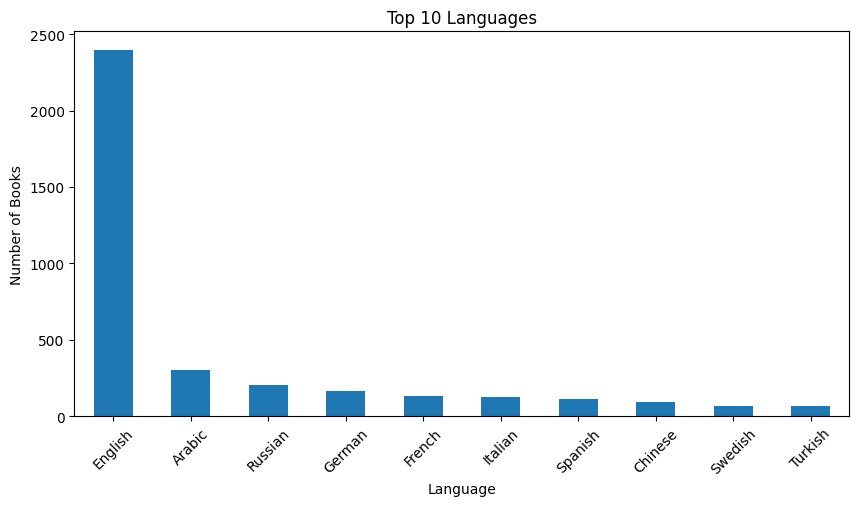


 DREAM BOOK SHOP ANALYSIS 
1. Publication Analysis
2. Author Analysis
3. Language Analysis
4. Publisher Analysis
5. ISBN Analysis
6. Exit


KeyboardInterrupt: Interrupted by user

In [53]:
main()

In [54]:
class YearLanguageAnalyzer:

    def __init__(self, df):
        self.df = df

    def analyze(self):

        result = self.df.groupby(
            ["publication date","language"]
        ).size()

        print(result.head())

        return result

In [56]:
class BaseAnalyzer:

    def __init__(self, df):
        self.df = df

    def analyze(self):
        pass

Publication Trend Summary
publication date
2011    290
2012    237
2013    135
2014    187
2015    333
2016    219
2017    352
2018    228
2019    530
2020    461
Name: count, dtype: int64


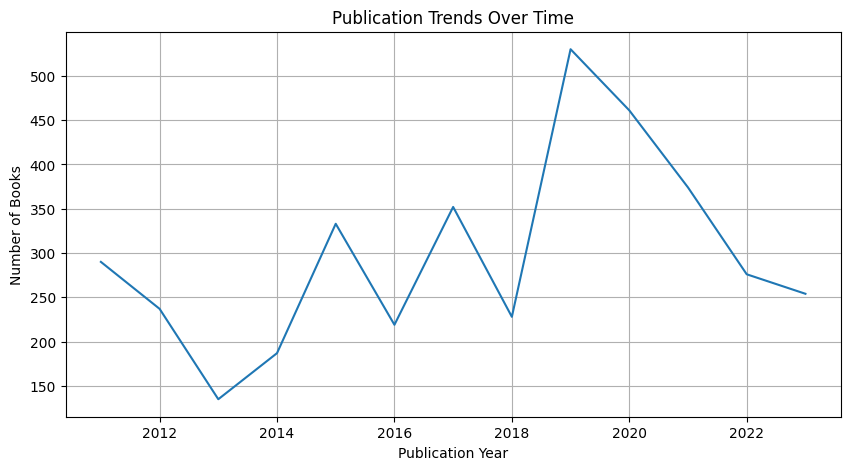

In [61]:
factory = AnalysisFactory(df)

publication = factory.create_analyzer("publication")
publication.analyze()
publication.plot()

In [62]:
class AnalysisStrategy:

    def execute(self):
        pass

In [63]:
class PublicationStrategy(AnalysisStrategy):

    def __init__(self, analyzer):
        self.analyzer = analyzer

    def execute(self):
        self.analyzer.analyze()
        self.analyzer.plot()

In [64]:
class AuthorStrategy(AnalysisStrategy):

    def __init__(self, analyzer):
        self.analyzer = analyzer

    def execute(self):
        self.analyzer.analyze()
        self.analyzer.plot()

In [65]:
import unittest
import pandas as pd

In [66]:
class TestBookAnalysis(unittest.TestCase):

    def setUp(self):
        self.df = pd.DataFrame({
            "publication date": [2020, 2021, 2021],
            "author": ["Author A", "Author B", "Author A"],
            "language": ["English", "Tamil", "English"],
            "publisher": ["Pub1", "Pub2", "Pub1"],
            "isbn": ["111", "222", "333"]
        })

    def test_dataset_not_empty(self):
        self.assertFalse(self.df.empty)

    def test_publication_column_exists(self):
        self.assertIn("publication date", self.df.columns)

    def test_author_column_exists(self):
        self.assertIn("author", self.df.columns)

    def test_language_column_exists(self):
        self.assertIn("language", self.df.columns)

In [67]:
unittest.main(argv=[''], exit=False)

....
----------------------------------------------------------------------
Ran 4 tests in 0.009s

OK
